# 第 04 章 降维与邻居图

## 学习目标

理解高维表达数据如何转化为用于展示和聚类的表示。

## 为什么做与怎样做

在高变基因上计算 50 个主成分，用 PCA 构建邻居图，并生成 t-SNE 与 UMAP。非线性图上的距离需要谨慎解释。

前置章节：03。运行前请完成项目环境准备。


In [1]:
from __future__ import annotations
from pathlib import Path
import os
import sys
ROOT = Path(os.environ.get("SC_COURSE_ROOT", Path.cwd())).resolve()
while not (ROOT / "config/course.json").is_file() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
if not (ROOT / "config/course.json").is_file():
    raise RuntimeError("请从课程目录或其 notebooks/exercises 目录运行。")
os.environ["CELLTYPIST_FOLDER"] = str(ROOT / ".runtime/celltypist")
os.environ["MPLCONFIGDIR"] = str(ROOT / ".runtime/matplotlib")
sys.path.insert(0, str(ROOT / "tools"))
from course_runtime import start_chapter, marker_sets, scaled_view
import anndata as ad
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import rc_context
from scipy.sparse import csr_matrix
from scipy.stats import median_abs_deviation
ctx = start_chapter("04")
adata = ctx.load_input()


第 04 章：降维与邻居图
结果目录：results/04_dimensionality/20260915T073130_f556ae


读取检查点：results/03_normalization_hvg/20260915T073055_538150/checkpoint.h5ad
17,041 个细胞 × 23,427 个基因


## 04.1 降维（Dimensionality Reduction）
通过主成分分析（PCA）降低数据维度，揭示主要变化轴并对数据去噪。

In [2]:
# 功能说明：在当前 `adata` 上计算 PCA 表达空间。
# 运行目的：提取主成分用于构建邻近图与后续聚类/可视化。
# 变量/函数/参数解析：
# - sc.tl.pca(adata)：
#   - 使用 `adata.X`（或 `.layers` 指定层）计算主成分并写入 `adata.obsm['X_pca']`。
# - use_highly_variable,bool | None (default: None),是否仅使用存储在.var['highly_variable']中的高变基因。默认情况下，如果事先已确定这些基因，则使用它们。
# - n_comps 要计算的主成分数量。默认值为50，
sc.tl.pca(adata, n_comps=ctx.config["parameters"]["n_pcs"], mask_var="highly_variable", random_state=0)

In [3]:
# 功能说明：查看 PCA 结果。
# 运行目的：检查 PCA 计算是否成功，并查看主成分矩阵的结构。
# 详细代码解析：
# 1. `adata.obsm`
#    - 查看 AnnData 对象的多维观测注释（observation matrices）。
#    - 应包含 `X_pca`。
# 2. `adata.obsm['X_pca']`
#    - 访问 PCA 坐标矩阵。
#    - 形状通常为 (n_obs, n_comps)，即每个细胞在 50 个主成分上的坐标。

adata.obsm
adata.obsm['X_pca']

array([[-2.6987646 , -1.9709301 , -0.8149002 , ..., -0.1725958 ,
         0.16420385, -0.5835457 ],
       [-5.0511017 ,  9.427235  , -1.200537  , ..., -0.47659028,
        -0.11966992,  0.23633583],
       [-2.5353909 , -1.7280554 ,  4.46401   , ...,  0.42603573,
         1.0445133 ,  0.3308557 ],
       ...,
       [10.959802  ,  1.5907967 ,  0.40137714, ..., -0.38637382,
        -0.20721482,  0.46706578],
       [ 0.04834585, -0.31775415, -1.3578708 , ...,  0.08694324,
        -0.8578079 , -0.9208832 ],
       [-1.955661  , -2.5468943 , -0.8949475 , ...,  0.28781766,
         0.38281354, -0.46773046]], shape=(17041, 50), dtype=float32)

让我们查看各主成分对总方差的贡献。这有助于确定用于构建细胞邻近关系（如 ~scanpy.tl.leiden 或 ~scanpy.tl.tsne）的主成分数量。经验上，适度高估主成分数量通常问题不大。

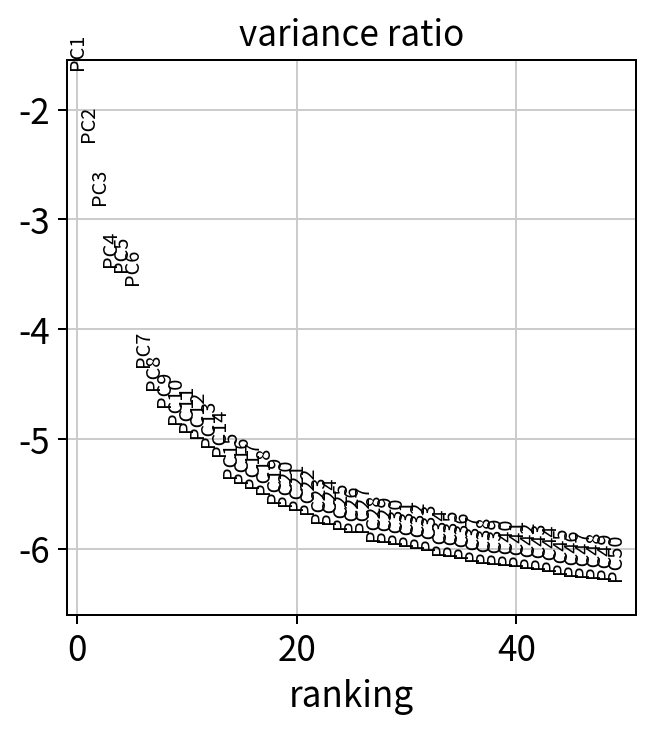

In [4]:
# 功能说明：绘制 PCA 方差占比图，观察前若干主成分的贡献。
# 运行目的：辅助选择用于邻近图与聚类的主成分数量。
# 变量/函数/参数解析：
# - sc.pl.pca_variance_ratio(adata, n_pcs=50, log=True)：
#   - n_pcs(int)：显示的主成分数量。
#   - log(bool)：对方差占比取对数显示，便于观察差异。

sc.pl.pca_variance_ratio(adata, n_pcs=50, log=True, save="_04_75.pdf")

也可直接绘制主成分空间，检查是否存在潜在的不期望因素（例如批次、QC 指标）驱动显著变化。本数据集中目前未见明显异常，但建议进行探索。
要判断PCA图中是否存在由批次、线粒体占比（pct_counts_mt）等不期望的技术因素驱动的“显著变化”，你需要观察点的分布与颜色之间的对应关系。
核心判断原则是：如果颜色（代表样本或QC指标）与点的聚集模式高度一致，则说明该因素对数据变异产生了主导性影响，这可能掩盖真实的生物学信号。
理想情况（无强批次效应）：不同样本（颜色）的点均匀混合在一起，像一盘五彩沙画，没有哪个颜色独自聚成一团。这意味着样本来源不同导致的变异很小。

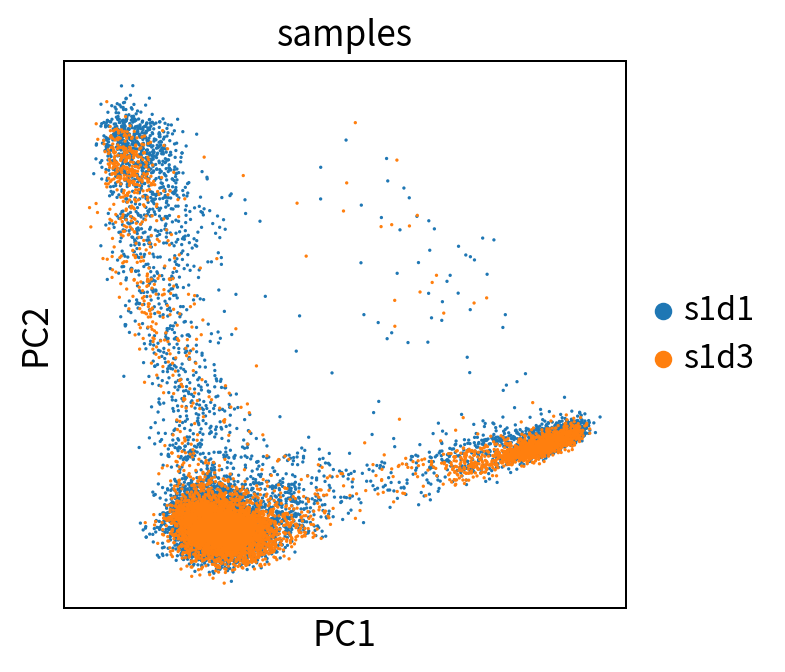

In [5]:
# 功能说明：绘制 PCA 散点图并按样本着色。
# 运行目的：在主成分空间中观察样本分布，初步评估是否存在批次效应。
# 详细代码解析：
# 1. `sc.pl.pca(...)`
#    - `adata`: AnnData 对象。
#    - `color='samples'`: 根据 `obs` 中的 `samples` 列对点进行着色。
#    - `save="..."`: 保存图像到文件。

sc.pl.pca(adata,color='samples',save="_04_77.pdf")

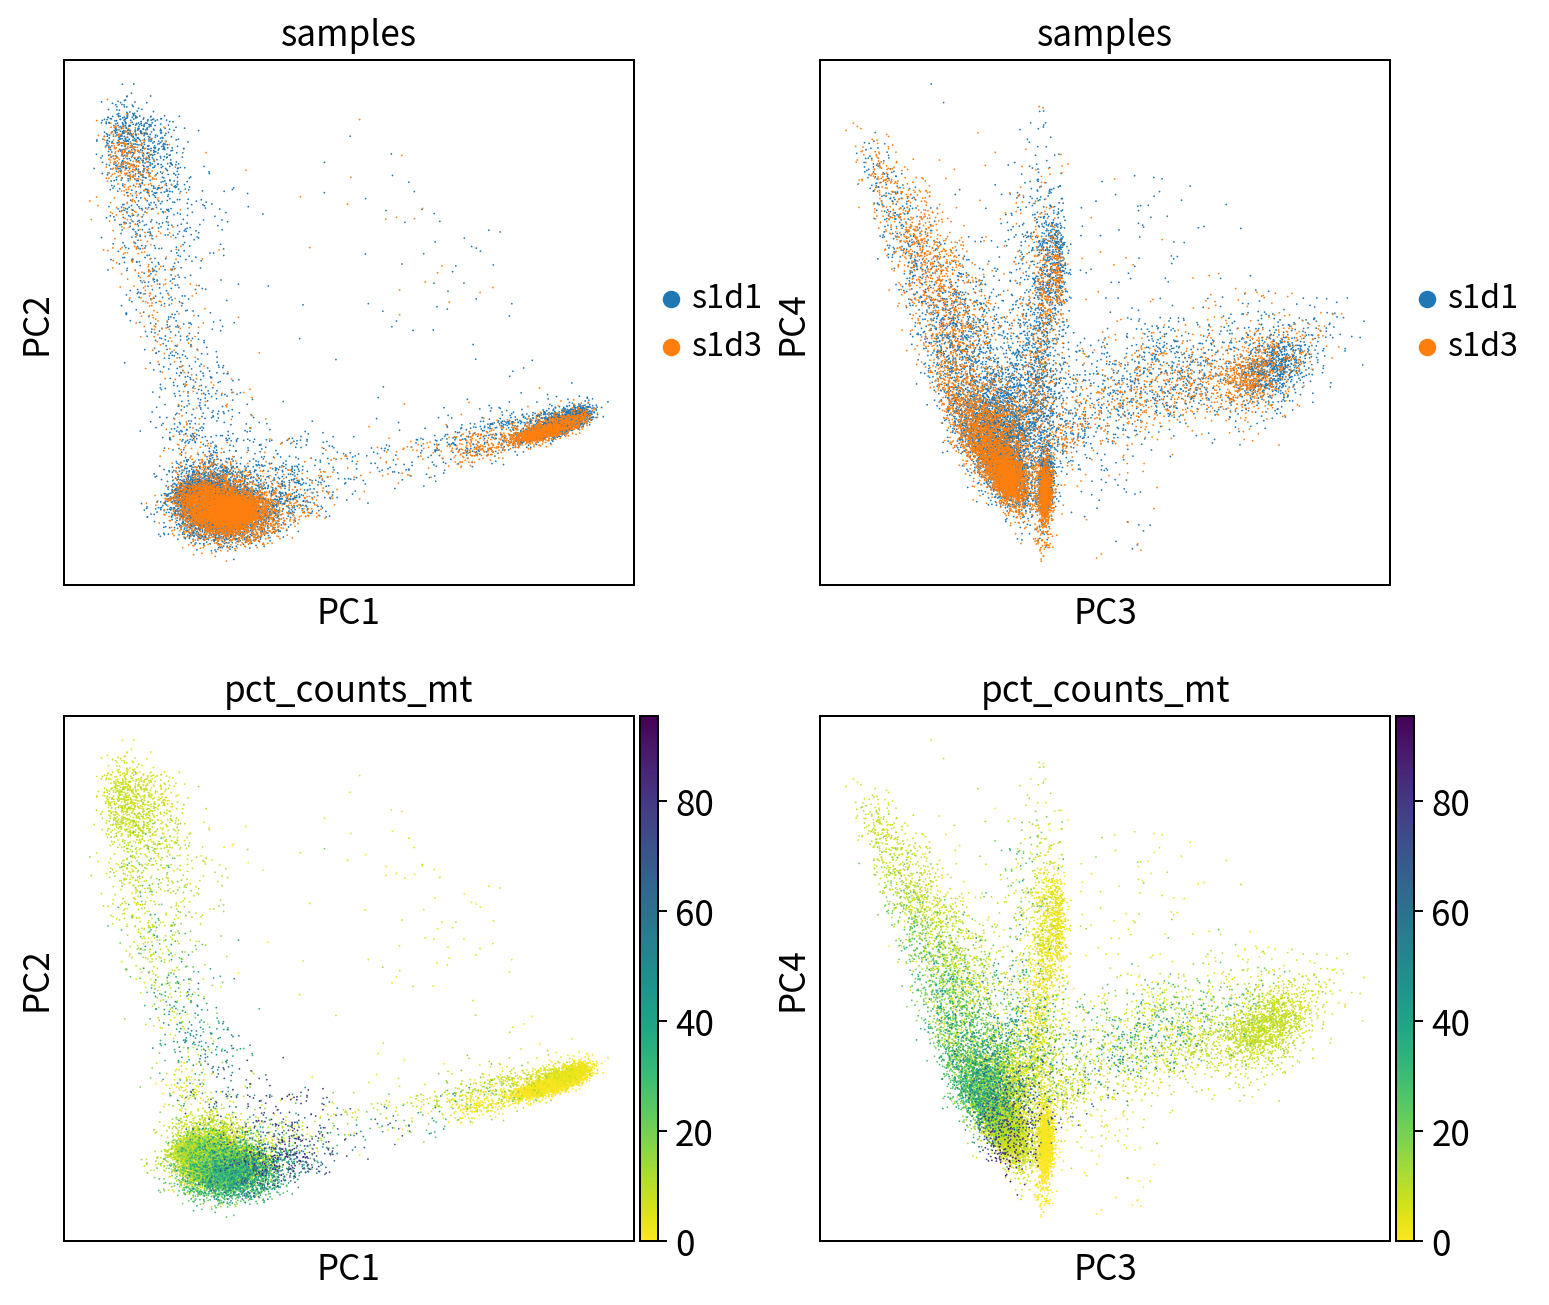

In [6]:
# 功能说明：在不同主成分维度上着色可视化，检查批次与 QC 影响。
# 运行目的：确认 PCA 空间中是否出现由样本或线粒体占比驱动的结构。
# 变量/函数/参数解析：
# - sc.pl.pca(adata, color=[...], dimensions=[...], ncols=2, size=2)：
#   - color(list)：按 `obs` 列着色，此处为样本与线粒体占比的重复组合。
#   - dimensions(list[tuple])：指定要绘制的主成分轴对。
#   - ncols(int)：每行图像面板数量。
#   - size(float)：点大小。
sc.pl.pca(
    adata,
    color=["samples", "samples", "pct_counts_mt", "pct_counts_mt"],
    dimensions=[(0, 1), (2, 3), (0, 1), (2, 3)],
    ncols=2,
    size=2,
    save="_04_78.pdf",
)

## 04.2 t-SNE与UMAP

In [7]:
# # 使用当前环境的 pip，而不是系统默认的 pip
# import sys
# !{sys.executable} -m pip install ipywidgets

## 04.3 t-SNE

t-SNE
t-SNE 是一种基于图的非线性降维技术，它将高维数据投影到 2D 或 3D 分量上。
该方法基于数据点之间的高维欧几里得距离定义高斯概率分布。
随后，使用 t-分布在低维空间中重建概率分布，其中嵌入使用梯度下降进行优化。

In [8]:
# 功能说明：执行 t-SNE 降维
# 运行目的：使用 t-SNE（t-Distributed Stochastic Neighbor Embedding）进行非线性降维，以便在二维平面上可视化高维数据的局部结构。
# 详细代码解析：
# 1. sc.tl.tsne(adata, use_rep="X_pca", random_state=0):
#    - 计算 t-SNE 嵌入。
#    - use_rep="X_pca": 使用之前计算的 PCA 结果（`adata.obsm['X_pca']`）作为输入，而不是原始表达矩阵。这样做可以减少噪声并显著加快计算速度。
#    - 结果将存储在 `adata.obsm['X_tsne']` 中。

sc.tl.tsne(adata, use_rep="X_pca", random_state=0)

/data/home/heqingchuan/workdir/19_方超老师合作_单细胞_gpt6/sc_RNA/sc_RNA_basic_course/.envs/sc_rna/lib/python3.12/site-packages/legacy_api_wrap/__init__.py:88: UserWarning: In previous versions of scanpy, calling tsne with n_jobs > 1 would use MulticoreTSNE. Now this uses the scikit-learn version of TSNE by default. If you'd like the old behaviour (which is deprecated), pass 'use_fast_tsne=True'. Note, MulticoreTSNE is not actually faster anymore.
  return fn(*args_all, **kw)


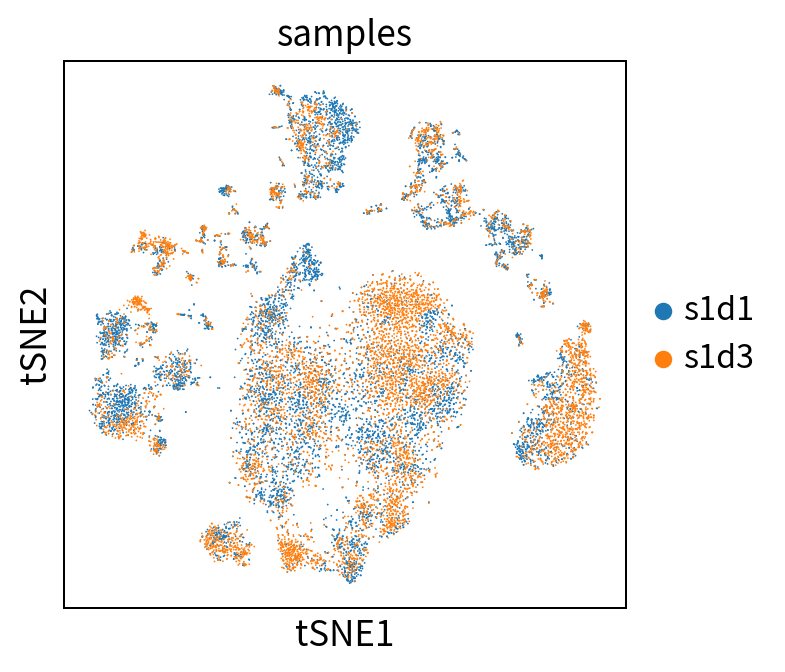

In [9]:
# 功能说明：绘制 t-SNE 散点图
# 运行目的：可视化 t-SNE 结果，观察细胞的聚类模式。
# 详细代码解析：
# 1. sc.pl.tsne(adata, color="total_counts"):
#    - 绘制 t-SNE 图。
#    - color="total_counts": 同样根据总计数着色，以检查技术协变量的影响。

sc.pl.tsne(adata, color="samples",size=2,save="_04_84.pdf",)

## 04.4 UMAP

UMAP绘制
UMAP 是一种基于图的非线性降维技术，在原理上与 t-SNE 相似。
它构建数据集的高维图表示，并优化低维图表示，使其在结构上尽可能与原始图相似。
我们首先计算 PCA，随后基于我们的数据创建邻域图。

In [10]:
# 功能说明：构建 K 邻近图以表征细胞间相似性。
# 运行目的：为后续 UMAP 可视化与 Leiden 聚类建立图结构基础。
# 变量/函数/参数解析：
# - sc.pp.neighbors(adata)：
#   - 默认在 `obsm['X_pca']` 空间中构建邻近图并存入 `adata.obsp`。
sc.pp.neighbors(adata,use_rep="X_pca",n_pcs=ctx.config["parameters"]["n_pcs"], random_state=0)

/data/home/heqingchuan/workdir/19_方超老师合作_单细胞_gpt6/sc_RNA/sc_RNA_basic_course/.envs/sc_rna/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [11]:
# 功能说明：查看 AnnData 对象的摘要信息。
# 运行目的：确认邻近图构建后，`uns` 和 `obsp` 中是否添加了相关信息。
# 详细代码解析：
# 1. `adata`
#    - 打印概览。
#    - `uns` 应包含 `neighbors`（邻居计算参数）。
#    - `obsp` 应包含 `distances`（距离矩阵）和 `connectivities`（连接矩阵）。

adata

AnnData object with n_obs × n_vars = 17041 × 23427
    obs: 'samples', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes', 'doublet_score', 'predicted_doublet'
    var: 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'hvg', 'log1p', 'samples_colors', 'scrublet', 'pca', 'tsne', 'neighbors'
    obsm: 'X_pca', 'X_tsne'
    varm: 'PCs'
    layers: 'counts', 'log1p'
    obsp: 'distances', 'connectivities'

In [12]:
# 功能说明：打印邻近图的连接矩阵。
# 运行目的：查看稀疏矩阵的结构，了解细胞间的连接情况。
# 详细代码解析：
# 1. `adata.obsp["connectivities"]`
#    - 获取细胞间的加权邻接矩阵（稀疏矩阵格式）。
#    - 非零元素表示两个细胞是邻居，值表示连接强度。

print(adata.obsp["connectivities"])

<Compressed Sparse Row sparse matrix of dtype 'float32'
	with 383734 stored elements and shape (17041, 17041)>
  Coords	Values
  (0, 2486)	0.17697787284851074
  (0, 2831)	0.25178447365760803
  (0, 2928)	0.08583877980709076
  (0, 3231)	0.0737374797463417
  (0, 3408)	1.0
  (0, 5734)	0.4165918231010437
  (0, 5984)	0.1760571300983429
  (0, 6469)	0.10255325585603714
  (0, 6752)	0.11167608201503754
  (0, 7269)	0.8688170909881592
  (0, 9299)	0.34531328082084656
  (0, 9784)	0.04430348053574562
  (0, 9928)	0.12050407379865646
  (0, 10691)	0.23438850045204163
  (0, 13678)	0.103379987180233
  (0, 15196)	0.13410523533821106
  (0, 16144)	0.7427018880844116
  (0, 16402)	0.3158758580684662
  (1, 2194)	0.11123085767030716
  (1, 4046)	0.5317400097846985
  (1, 4273)	0.10857492685317993
  (1, 4352)	0.06836285442113876
  (1, 6048)	0.261935293674469
  (1, 6171)	0.1252954751253128
  (1, 6839)	0.07445641607046127
  :	:
  (17039, 16303)	0.21924039721488953
  (17039, 16854)	0.31504252552986145
  (17040, 3394)	

随后可使用 UMAP {cite:p}`McInnes2018` 将该图嵌入到二维空间以便可视化：

In [13]:
# UMAP 的核心思想是：在低维空间中保持高维空间中邻居关系的拓扑结构，直接使用邻居图（sc.pp.neighbors()结果）作为输入，而不是原始矩阵
# 运行时间相对较久
# 功能说明：计算 UMAP 嵌入以获得二维可视化坐标。
# 运行目的：在二维平面展示细胞间的结构关系。
# 变量/函数/参数解析：
# - sc.tl.umap(adata)：
#   - 使用已构建的邻近图进行低维嵌入，结果写入 `obsm['X_umap']`。
sc.tl.umap(adata,neighbors_key="neighbors", random_state=0)

现在可以按 `samples` 对 UMAP 进行着色可视化。

t-SNE	强调保留局部结构。它会让高维空间里临近的点在2D图上依然紧挨，但会大幅拉开不同簇群之间的距离。		

特点：簇间距离无意义。同一个簇在两次运行中形状可能完全不同。

图例：坐标轴（t-SNE1/2）没有单位，不能比较距离绝对值。

UMAP更好地平衡局部与全局结构。既能保持相邻细胞的接近，也在一定程度上保留了簇群间的相对位置和大小关系。		

特点：运行更快，全局结构保持更好，是目前的主流选择。

图例：坐标轴（UMAP1/2）同样没有实际单位，但相对布局更具参考性。

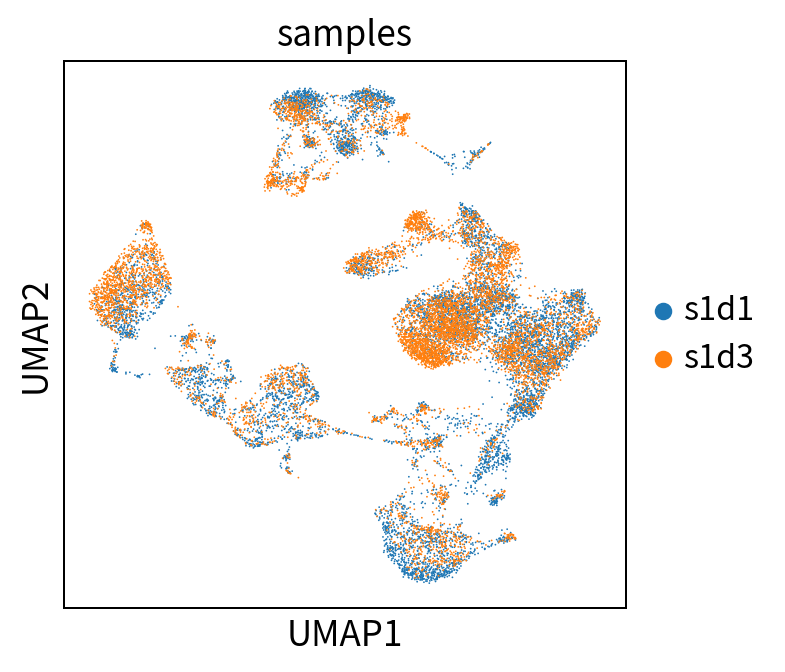

In [14]:
# 功能说明：绘制 UMAP 并按样本着色。
# 运行目的：评估批次/样本间的分离程度与混合情况。
# 变量/函数/参数解析：
# - sc.pl.umap(adata, color="samples", size=2)：
#   - color(str/list)：着色列，此处为样本标签。
#   - size(float)：点大小，设小以减少重叠。

sc.pl.umap(
    adata,
    color="samples",
    # 设置较小点大小以减少重叠
    size=2,
    save="_04_93.pdf"
)


In [15]:
# 功能说明：查看 AnnData 对象的摘要信息。
# 运行目的：确认 UMAP 计算后，`obsm` 中是否添加了 `X_umap`。
# 详细代码解析：
# 1. `adata`
#    - 打印概览。
#    - `obsm` 应包含 `X_umap`。

adata

AnnData object with n_obs × n_vars = 17041 × 23427
    obs: 'samples', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes', 'doublet_score', 'predicted_doublet'
    var: 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'hvg', 'log1p', 'samples_colors', 'scrublet', 'pca', 'tsne', 'neighbors', 'umap'
    obsm: 'X_pca', 'X_tsne', 'X_umap'
    varm: 'PCs'
    layers: 'counts', 'log1p'
    obsp: 'distances', 'con

In [16]:
# 功能说明：查看 UMAP 坐标矩阵。
# 运行目的：检查 UMAP 嵌入结果的数据结构。
# 详细代码解析：
# 1. `adata.obsm['X_umap']`
#    - 获取每个细胞的 2D UMAP 坐标。
#    - 形状为 (n_obs, 2)。

adata.obsm['X_umap']

array([[10.871283 ,  9.116476 ],
       [ 7.8730903, -3.383662 ],
       [ 5.11598  , 18.656256 ],
       ...,
       [ 2.899358 ,  4.9984584],
       [12.805622 ,  6.2066326],
       [ 9.315851 ,  7.7984   ]], shape=(17041, 2), dtype=float32)

尽管本教程数据包含两个不同样本，我们仅观察到较轻的批次效应，可以继续进行聚类与细胞类型注释。

若在 UMAP 中观察到明显的批次效应，建议在样本之间进行整合与批次校正。可参考 [`scanorama`](https://github.com/brianhie/scanorama) 与 [`scvi-tools`](https://scvi-tools.org)。

## 保存本章结果

保存表格、参数摘要和可供后续章节读取的数据。

In [17]:
ctx.table("pca_variance", pd.DataFrame({"PC": np.arange(1, len(adata.uns["pca"]["variance_ratio"]) + 1), "variance_ratio": adata.uns["pca"]["variance_ratio"]}), index=False)
ctx.table("embedding", pd.DataFrame(adata.obsm["X_umap"], index=adata.obs_names, columns=["UMAP1", "UMAP2"]).join(adata.obs[["samples"]]))
ctx.finish(adata, {"n_pcs": adata.obsm["X_pca"].shape[1], "variance_ratio_first_10": float(adata.uns["pca"]["variance_ratio"][:10].sum())})

本章计算完成。请阅读本次图表和表格，再更新本章解读。


## 结果阅读与思考

请打开本次结果目录中的 summary.json、tables 和 figures。将目的、方法、结果和解释写入本章报告源稿，再更新 Word。

思考题：UMAP 上两个群体相距较远，能否直接解释为发育关系较远？

运行与报告操作见课程根目录的 99_运行与AI协作指南.md。